# Projet Python pour la data science

## Import et installation des packages nécessaires

On commence par importer et installer les packages nécessaires au projet. Les packages à installer sont recensés dans le fichier requirements.txt.

In [3]:
!pip install -q -r requirements.txt

In [4]:
import os
import requests
import pandas as pd

## Récupération des données

Nous allons télécharger les données à partir de l'URL. (à expliquer mieux)

On commence par définir les variables et fonctions utiles à la récupération des données.

In [5]:
DATA_PATH = "data/maladies_chroniques.csv"
URL = "https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/csv?use_labels=true"


def download_data():
    os.makedirs("data", exist_ok=True)
    
    if not os.path.exists(DATA_PATH):
        print("Téléchargement des données...")
        r = requests.get(URL)
        with open(DATA_PATH, "wb") as f:
            f.write(r.content)
        print("Téléchargement terminé.")
    else:
        print("Fichier déjà présent.")


def load_data():
    return pd.read_csv(DATA_PATH, sep=";", encoding="utf-8")

Maintenant que l'on a tous les outils, on peut passer à la récupération des données.

In [6]:
download_data()
df = load_data()
df.head()

Fichier déjà présent.


,type,varTaux,varTauxLib,I_cat,cat,catLib,varPartition,valPartition,varGroupage,valGroupage,varPoids,poids1,poidsTot,txNonStand,txStandDir,txStandDirModBB,txStandDirModBH,txStandIndir,txStandIndirModBB,txStandIndirModBH
0,incidence,TOP_CVIC_CHR,Insuffisance cardiaque chronique,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,NaN,NaN,POIDS_FIDELI_S,30116.961505,6.302392e+06,0.004779,0.004779,0.004521,0.005037,0.004779,0.004521,0.005037
1,incidence,TOP_PRETARD_IND,Déficience mentale,0,SUP_PSYPAT_CAT,Maladies psychiatriques,FISC_REG_S,28,NaN,NaN,POIDS_FIDELI_S,1309.430271,6.349002e+06,0.000206,0.000206,0.000150,0.000263,0.000206,0.000150,0.000263
2,incidence,TOP_RTRANS_CHR,Suivi de transplantation rénale,0,SUP_RIRCT_CAT,Insuffisance rénale chronique terminale,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,1,POIDS_FIDELI_S,0.000000,5.294220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,incidence,TOP_CVTRRYC_IND,Troubles du rythme ou de la conduction cardiaque,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,2,POIDS_FIDELI_S,6959.005587,6.266976e+05,0.011104,0.011745,0.010400,0.013090,0.011888,0.010576,0.013201
4,incidence,TOP_IRHEMOP_IND,Hémophilie ou troubles de l'hémostase graves,0,SUP_INFRARVIH_CAT,Maladies inflammatoires ou rares ou VIH ou SIDA,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,2,POIDS_FIDELI_S,92.865604,6.438119e+05,0.000144,0.000147,-0.000005,0.000300,0.000154,-0.000004,0.000312


On peut le faire par API (c'est mieux je pense, les deux donnent la même chose à la fin donc il faut choisir la meilleure méthode).

In [5]:
url = "https://www.data.gouv.fr/api/1/datasets/inegalites-sociales-face-aux-maladies-chroniques-er-1243/"

response = requests.get(url)
data = response.json()

print(data.keys())

dict_keys(['access_audiences', 'access_type', 'access_type_reason', 'access_type_reason_category', 'acronym', 'archived', 'authorization_request_url', 'badges', 'contact_points', 'created_at', 'deleted', 'description', 'description_short', 'extras', 'featured', 'frequency', 'frequency_date', 'harvest', 'id', 'internal', 'last_modified', 'last_update', 'license', 'metrics', 'organization', 'owner', 'page', 'permissions', 'private', 'quality', 'resources', 'schema', 'slug', 'spatial', 'tags', 'temporal_coverage', 'title', 'uri'])


In [6]:
resources = data["resources"]

for r in resources:
    print(r["title"], r["url"])

er_inegalites_maladies_chroniques.csv https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/csv?use_labels=true
er_inegalites_maladies_chroniques.json https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/json
ex_analyse_maladies_chroniques.R https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/ex_analyse_maladies_chroniques_r
libelles_er1243.xlsx https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/libelles_er1243_xlsx


In [2]:
csv_url = resources[0]["url"]  # adapte si plusieurs fichiers
df = pd.read_csv(csv_url, sep=";")

df.head()

NameError: name 'resources' is not defined

## Visualisation 

Nous allons commencer la visulation des données.
Nous allons avoir besoin de véifier si le nombre de variable est suffisant et de voir comment la base de données est faite.

In [7]:

print(f"Le fichier contient {df.shape[0]} lignes (observations) et {df.shape[1]} colonnes (variables).")

print("\n--- Structure du jeu de données ---")
print(df.info())

print("\n--- Liste des noms de variables ---")
print(df.columns.tolist())

Le fichier contient 46176 lignes (observations) et 20 colonnes (variables).

--- Structure du jeu de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46176 entries, 0 to 46175
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               46176 non-null  object 
 1   varTaux            46176 non-null  object 
 2   varTauxLib         46176 non-null  object 
 3   I_cat              46176 non-null  int64  
 4   cat                46176 non-null  object 
 5   catLib             46176 non-null  object 
 6   varPartition       43160 non-null  object 
 7   valPartition       43160 non-null  object 
 8   varGroupage        44408 non-null  object 
 9   valGroupage        44408 non-null  object 
 10  varPoids           46176 non-null  object 
 11  poids1             46172 non-null  float64
 12  poidsTot           46172 non-null  float64
 13  txNonStand         46172 non-null  float64
 14  txSta

Nous possédons ainsi plus de 46000 obsevrations pour 20 variables dans notre base de données.


Nous cherchons ainsi dans un premier temps à visuliser si il y a des différences de taux de maladies chroniques entre les différents niveaux de vie. 
Pour commencer , voyons tout d'abords la proportions de ces maladies en fonctions de l'âge.

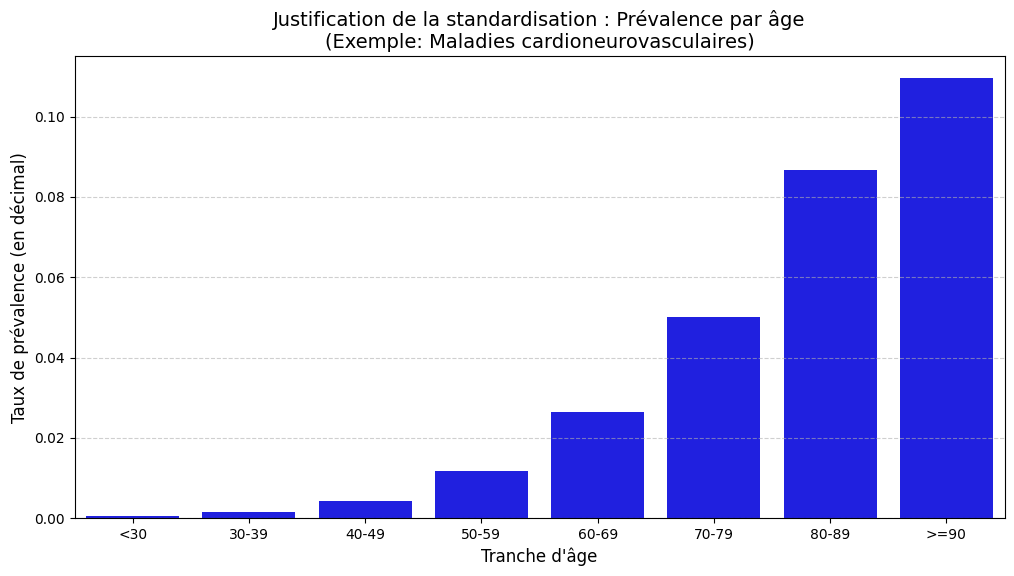

In [ ]:

df_age_bis = df[(df['type'] == 'prevalence') & 
            (df['varGroupage'] == 'classeAge10') & 
            (df['varPartition'].isna()) &
            (df['catLib'] == 'Maladies cardioneurovasculaires')].copy()

ordre_age = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90']

df_age_bis_bis['valGroupage'] = pd.Categorical(df_age_bis['valGroupage'], categories=ordre_age, ordered=True)

df_age_bis = df_age_bis.sort_values('valGroupage')

plt.figure(figsize=(12, 6))

sns.barplot(data=df_age_bis, x='valGroupage', y='txNonStand', color="blue", order=ordre_age, errorbar=None)

plt.title("Justification de la standardisation : Prévalence par âge\n(Exemple: Maladies cardioneurovasculaires)", fontsize=14)
plt.xlabel("Tranche d'âge", fontsize=12)
plt.ylabel("Taux de prévalence (en décimal)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.show()

On remaque directement que comme prévu, l'âge est un facteur déterminent dans cette étude. On remarque à l'aide de ce graphuique que le taux de prévalence explose avec l'âge. Afin de mener une étude sur les critères sociaux et non sur l'âge nous allons essayer d'effacer ce facteur. 
Pour cela la base de données dispose de données stadardisé par rapport à l'âge, voyons à quoi cela ressmeble et si elle efface bien l'effet de l'âge.

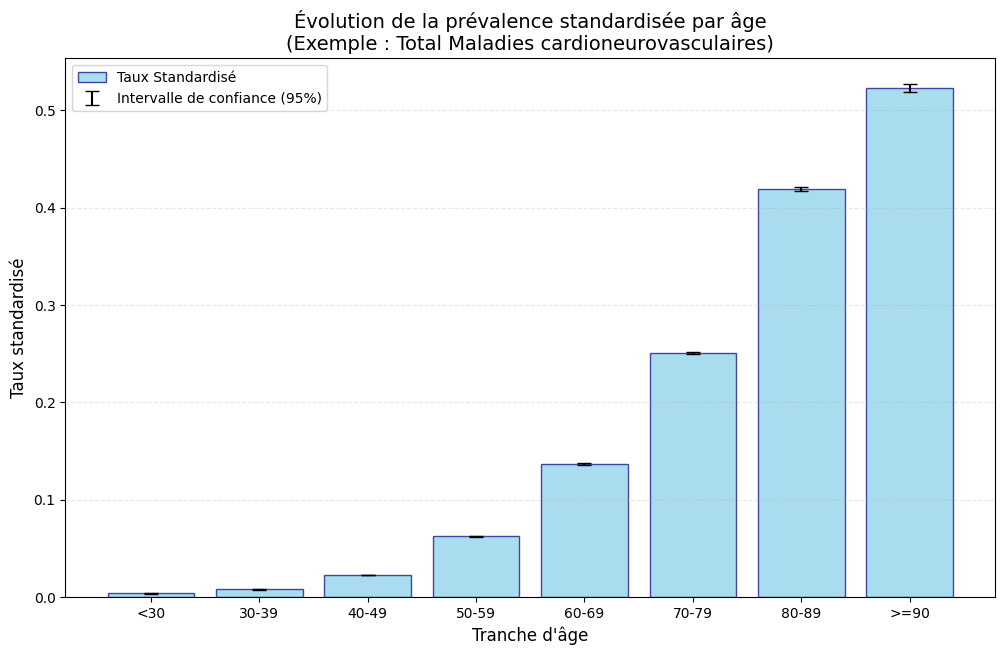

In [28]:

df_age_bis = df[
    (df['type'] == 'prevalence') & 
    (df['varGroupage'] == 'classeAge10') & 
    (df['varPartition'].isna()) &
    (df['varTauxLib'] == 'Maladies cardioneurovasculaires') # On prend le TOTAL uniquement
].copy()

df_age_bis = df_age_bis.dropna(subset=['valGroupage', 'txStandDir'])

ordre_age = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90']
df_age_bis['valGroupage'] = pd.Categorical(df_age_bis['valGroupage'], categories=ordre_age, ordered=True)
df_age_bis = df_age_bis.sort_values('valGroupage')

erreur_inf = df_age_bis['txStandDir'] - df_age_bis['txStandDirModBB']
erreur_sup = df_age_bis['txStandDirModBH'] - df_age_bis['txStandDir']
erreurs = [erreur_inf, erreur_sup]

plt.figure(figsize=(12, 7))

plt.bar(df_age_bis['valGroupage'].astype(str), df_age_bis['txStandDir'], 
        color='skyblue', edgecolor='navy', alpha=0.7, label='Taux Standardisé')

plt.errorbar(x=df_age_bis['valGroupage'].astype(str), y=df_age_bis['txStandDir'], 
             yerr=erreurs, fmt='none', ecolor='black', capsize=5, label='Intervalle de confiance (95%)')

plt.title("Évolution de la prévalence standardisée par âge\n(Exemple : Total Maladies cardioneurovasculaires)", fontsize=14)
plt.ylabel("Taux standardisé", fontsize=12)
plt.xlabel("Tranche d'âge", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()

plt.show()



## Modélisation